**Part A: Data Preprocessing**

In [195]:
#load dataset
import pandas as pd

df = pd.read_csv("/content/Student Awareness Survey (Responses) - Form Responses 1.csv")

df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [196]:
#dataset specifications
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe(include='all'))


#missing values
print("\nMissing Values:")
print(df.isnull().sum())

#duplicate values
print("\nDuplicate Records:")
print(df.duplicated().sum())



Shape: (50, 15)

Columns:
Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                        

**Interpretation**
*   The dataset contains 50 records and 15 attributes collected through the survey.
*   Missing values were found in the CIA and Attendance columns. Since the dataset is small, median imputation was used to avoid losing data.
*   No duplicate records were found in the dataset.
*   The summary statistics provide information such as mean, minimum, maximum, and spread of the numerical variables. This helps understand the overall distribution of the data.













In [197]:
#converting required columns to numeric

cols = [
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df[cols].dtypes)

Your CIA % of last semester                     float64
Your GPA of last semester                       float64
Your maximum attendance % till last semester    float64
dtype: object


In [198]:
print(df[cols].isnull().sum())

cols2 = [
    'Your CIA % of last semester',
    'Your maximum attendance % till last semester'
]

for c in cols2:
    df[c].fillna(df[c].median(), inplace=True)

print(df[cols].isnull().sum())

Your CIA % of last semester                     10
Your GPA of last semester                        0
Your maximum attendance % till last semester    10
dtype: int64
Your CIA % of last semester                     0
Your GPA of last semester                       0
Your maximum attendance % till last semester    0
dtype: int64


/tmp/ipykernel_1983/3842554330.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)


In [199]:
# handling invalid GPA values (>4)

print(df[df['Your GPA of last semester'] > 4])

df.loc[
    df['Your GPA of last semester'] > 4,
    'Your GPA of last semester'
] = df['Your GPA of last semester'].median()

print(df['Your GPA of last semester'].max())

            Timestamp  Registration Number  \
13  6/15/2026 9:57:04              2547247   

                                    Email  \
13  sharon.mathew@mca.christuniversity.in   

    Job role that you are interested in  \
13  Software Development Engineer (SDE)   

   What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
13                                                  4                                           

   What is the maximum salary of students placed through campus (In LPA..respond as a number)  \
13                                                 12                                           

   What is the median salary of students placed through campus (In LPA..respond as a number)  \
13                                                8-9                                          

   Which is the highest paying company that recruits from campus?  \
13                                Adobe and Akasa Air               

    Rat

**Interpretation**

One GPA value was found outside the valid range of 0–4 and was treated as a data entry error. It was replaced with the median GPA value.

**Experiment 1:**
**CIA → GPA**

In [200]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#defining dependent & independent variables

X1 = df[['Your CIA % of last semester']]

y1 = df['Your GPA of last semester']



In [201]:
# train-test split
X1_train,X1_test,y1_train,y1_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)


# training model
model1 = LinearRegression()

model1.fit(X1_train,y1_train)


print("Slope:",model1.coef_[0])
print("Intercept:",model1.intercept_)


# making predictions
y1_pred = model1.predict(X1_test)

print(y1_pred)


Slope: 0.011537523955379088
Intercept: 2.5647369448946122
[2.64549961 3.38840078 3.48773886 3.43005124 3.38840078 3.38840078
 3.37236362 3.39543867 3.38840078 3.39290041]


The slope indicates how much GPA changes for a unit increase in the independent variable, while the intercept represents the predicted GPA when the independent variable is zero.


**Interpretation**

The model predicts GPA values based on CIA percentage. Most predicted GPAs lie close to the actual GPA range, indicating that the model captures the general trend in the data.

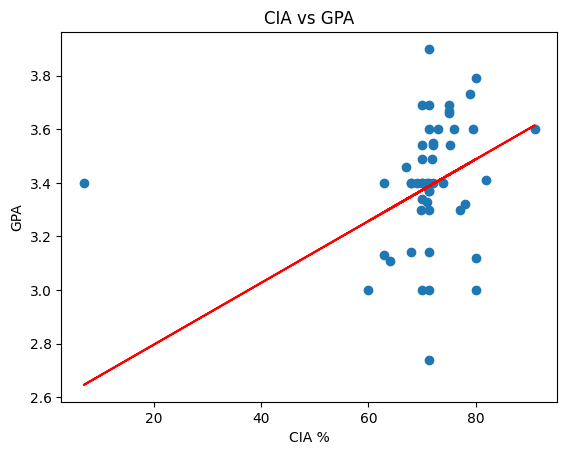

In [202]:
import matplotlib.pyplot as plt

plt.scatter(X1,y1)

plt.plot(
    X1,
    model1.predict(X1),
    color='red'
)

plt.xlabel("CIA %")

plt.ylabel("GPA")

plt.title("CIA vs GPA")

plt.show()

**Interpretation**

The graph shows a positive relationship between CIA and GPA. In general, students with higher CIA scores tend to have higher GPAs, although a few exceptions are present.

**Part C : Manual OLS**

In [203]:
# computing slope & intercept

x1 = df['Your CIA % of last semester']

y1 = df['Your GPA of last semester']

m1 = (
    ((x1-x1.mean())*(y1-y1.mean())).sum()
    /
    ((x1-x1.mean())**2).sum()
)

c1 = y1.mean() - m1*x1.mean()

print("Slope:",m1)

print("Intercept:",c1)

# manual prediction
y1_manual = m1*x1 + c1

print(y1_manual.head())

Slope: 0.0034845150977070184
Intercept: 3.1575840961963717
0    3.398016
1    3.418923
2    3.443314
3    3.474675
4    3.401500
Name: Your CIA % of last semester, dtype: float64


In [204]:
print("Comparison: \n")

comparison1 = pd.DataFrame({

    'Actual GPA':y1,

    'Sklearn Prediction':
        model1.predict(X1),

    'Manual OLS':
        y1_manual

})

comparison1['Difference'] = abs(

    comparison1['Sklearn Prediction']

    -

    comparison1['Manual OLS']

)

comparison1.head()

Comparison: 



,Actual GPA,Sklearn Prediction,Manual OLS,Difference
0,3.40,3.360826,3.398016,0.037190
1,3.69,3.430051,3.418923,0.011129
2,3.41,3.510814,3.443314,0.067500
3,3.60,3.614652,3.474675,0.139977
4,3.54,3.372364,3.401500,0.029137


**Interpretation**

The predictions obtained using Scikit-learn and manual OLS are very similar. The differences between the two methods are very small, showing that both approaches produce almost the same regression model.

**Experiment 2: Attendance -> GPA**



In [205]:
#defining dependent & independent variables

X2 = df[['Your maximum attendance % till last semester']]

y2 = df['Your GPA of last semester']

In [206]:
# train-test split
X2_train,X2_test,y2_train,y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)


# training model
model2 = LinearRegression()

model2.fit(X2_train,y2_train)


print("Slope:",model2.coef_[0])
print("Intercept:",model2.intercept_)


# making predictions
y2_pred = model2.predict(X2_test)

print(y2_pred)

Slope: 0.01269537480063796
Intercept: 2.2033652312599687
[3.40942584 3.40942584 3.47290271 3.40942584 3.40942584 3.34594896
 3.42212121 3.38403509 3.40942584 3.42897671]


**Interpretation**

The model predicts GPA values based on attendance percentage. The predicted GPAs are within the expected range, but the relationship between attendance and GPA appears weaker compared to CIA and GPA.

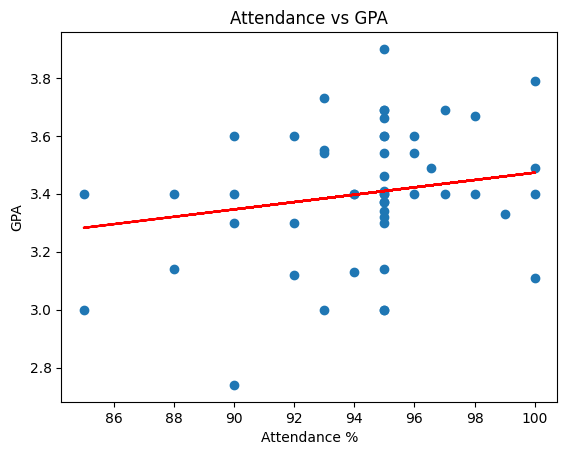

In [207]:
plt.scatter(X2,y2)

plt.plot(
    X2,
    model2.predict(X2),
    color='red'
)

plt.xlabel("Attendance %")

plt.ylabel("GPA")

plt.title("Attendance vs GPA")

plt.show()

**Interpretation**

The graph shows a weak positive relationship between attendance and GPA. Students with higher attendance tend to have slightly higher GPAs, but attendance alone does not strongly determine GPA.

**Part C : Manual OLS**

In [208]:
# computing slope & intercept

x2 = df['Your maximum attendance % till last semester']

y2 = df['Your GPA of last semester']

m2 = (
    ((x2-x2.mean())*(y2-y2.mean())).sum()
    /
    ((x2-x2.mean())**2).sum()
)

c2 = y2.mean() - m2*x2.mean()

print("Slope:",m2)

print("Intercept:",c2)

# manual prediction
y2_manual = m2*x2 + c2

print(y2_manual.head())

Slope: 0.020673643409220795
Intercept: 1.4556656240298436
0    3.481683
1    3.419662
2    3.419662
3    3.357641
4    3.378314
Name: Your maximum attendance % till last semester, dtype: float64


In [209]:
print("Comparison: \n")

comparison2 = pd.DataFrame({

    'Actual GPA':y2,

    'Sklearn Prediction':
        model2.predict(X2),

    'Manual OLS':
        y2_manual

})

comparison2['Difference'] = abs(

    comparison2['Sklearn Prediction']

    -

    comparison2['Manual OLS']

)

comparison2.head()

Comparison: 



,Actual GPA,Sklearn Prediction,Manual OLS,Difference
0,3.40,3.447512,3.481683,0.034171
1,3.69,3.409426,3.419662,0.010236
2,3.41,3.409426,3.419662,0.010236
3,3.60,3.371340,3.357641,0.013699
4,3.54,3.384035,3.378314,0.005721


**Interpretation**

Although the relationship between attendance and GPA is weak, both Scikit-learn and manual OLS capture the same trend and produce similar predictions.

**Pickle saving**

Training a model every time can be time-consuming. Pickle is used to save the learned model parameters (slope and intercept) into a file so that they can be loaded later and used for prediction without training the model again.

In [210]:
import pickle

params = {

    'CIA_GPA': {

        'slope': model1.coef_[0],

        'intercept': model1.intercept_

    },

    'Attendance_GPA': {

        'slope': model2.coef_[0],

        'intercept': model2.intercept_

    }

}
with open(
    'linear_regression_weights.pkl',
    'wb'
) as f:

    pickle.dump(params,f)

In [211]:
#loading pickle

with open(
    'linear_regression_weights.pkl',
    'rb'
) as f:

    loaded = pickle.load(f)

print(loaded)

{'CIA_GPA': {'slope': np.float64(0.011537523955379088), 'intercept': np.float64(2.5647369448946122)}, 'Attendance_GPA': {'slope': np.float64(0.01269537480063796), 'intercept': np.float64(2.2033652312599687)}}


**Interpretation**

The Pickle file was loaded successfully and contains the slope and intercept values for both regression models — CIA vs GPA and Attendance vs GPA. These stored parameters can now be used to make predictions without retraining the models.

Prediction using CIA → GPA model(taking CIA = 80)

In [212]:
x3 = 80

y3 = (

    loaded['CIA_GPA']['slope'] * x3

    +

    loaded['CIA_GPA']['intercept']

)

print("Predicted GPA:", y3)

Predicted GPA: 3.487738861324939


**Interpretation**

For a CIA score of 80%, the model predicts a GPA of approximately 3.49. This prediction is within the valid GPA range and indicates a good academic performance according to the trained model.

Prediction using Attendance → GPA model(taking Attendance = 90)

In [213]:
x4 = 90

y4 = (

    loaded['Attendance_GPA']['slope'] * x4

    +

    loaded['Attendance_GPA']['intercept']

)

print("Predicted GPA:", y4)

Predicted GPA: 3.345948963317385


**Interpretation**

For an attendance of 90%, the model predicts a GPA of approximately 3.35. This shows that the trained model can estimate GPA based on attendance percentage.